Processing all samples with bbox generation + gaze mapping


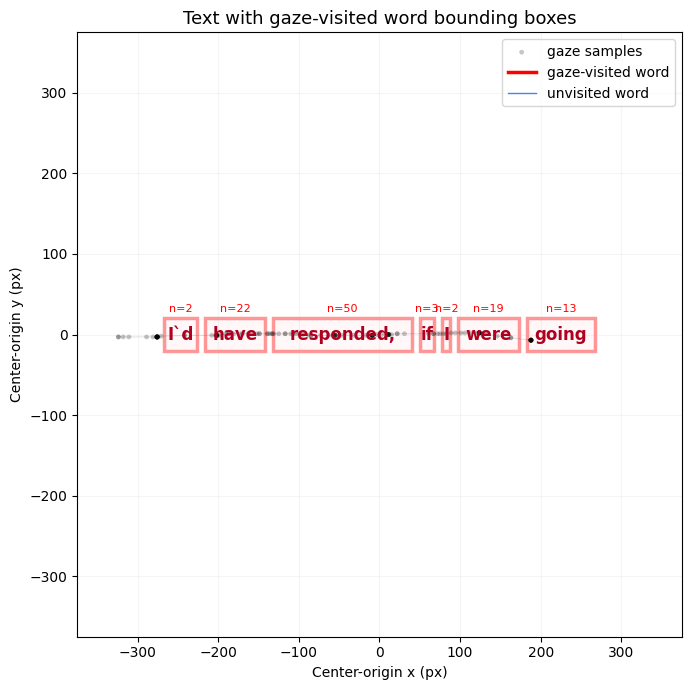

Visited words: ['I`d', 'have', 'responded,', 'if', 'I', 'were', 'going']
Gaze samples per word: {'I`d': 2, 'have': 22, 'responded,': 50, 'if': 3, 'I': 2, 'were': 19, 'going': 13}


In [6]:
from tobii_pytracker.analyze.data_loader import DataLoader
from tobii_pytracker.configs.custom_config import CustomConfig
from tobii_pytracker.datasets.custom_dataset import TextDataset
from tobii_pytracker.analyze.models import BBoxTextAnalyzer

from pathlib import Path
import pandas as pd
from IPython.display import display


config = CustomConfig('./configs/config.yaml')
loader = DataLoader(config, root='./')
output_dir = Path("./analysis_outputs/text_demo")
output_dir.mkdir(parents=True, exist_ok=True)

print('Processing all samples with bbox generation + gaze mapping')

gaze_data = loader.get_all_data(flatten=True)


if gaze_data.empty:
    raise ValueError('No gaze samples found in any run.')



gaze_data['set_name'] = gaze_data['set_name'].astype(str)
gaze_data['slide_index'] = pd.to_numeric(gaze_data['slide_index'], errors='coerce').astype('Int64')

analyzer = BBoxTextAnalyzer(output_folder=output_dir,config=config)
set_name = gaze_data['set_name'].astype(str)[0]
slide_index =0
selected_gaze = gaze_data[(gaze_data['set_name'] == set_name) & (gaze_data['slide_index'] == slide_index)].copy()
results = analyzer.analyze(selected_gaze)
analyzer.plot_analysis(results)


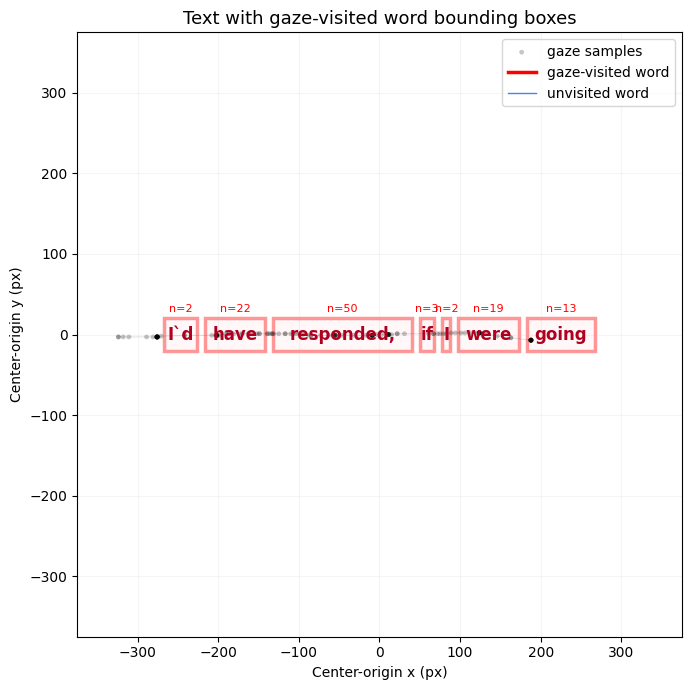

Visited words: ['I`d', 'have', 'responded,', 'if', 'I', 'were', 'going']
Gaze samples per word: {'I`d': 2, 'have': 22, 'responded,': 50, 'if': 3, 'I': 2, 'were': 19, 'going': 13}


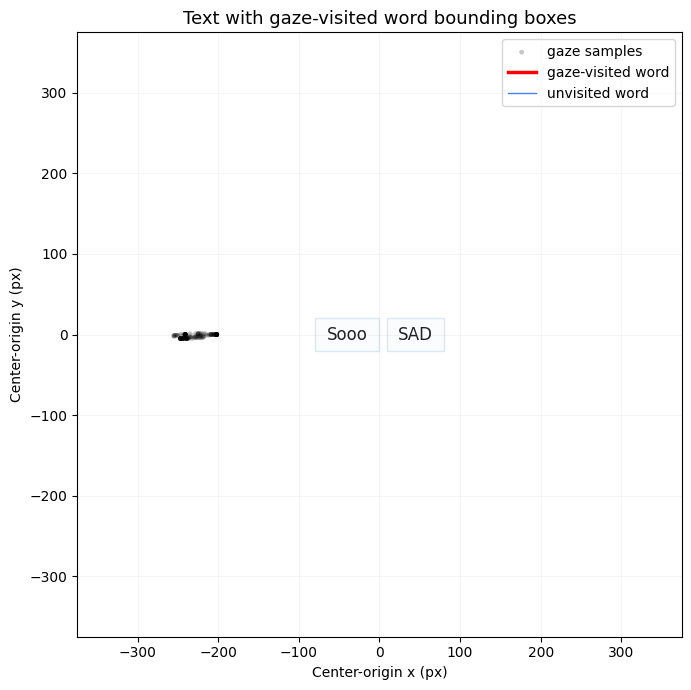

Visited words: []
Gaze samples per word: {'Sooo': 0, 'SAD': 0}


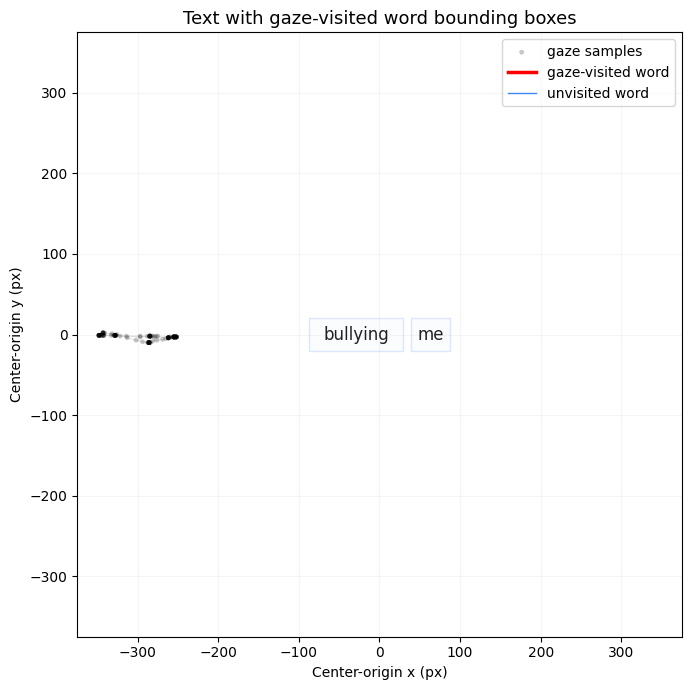

Visited words: []
Gaze samples per word: {'bullying': 0, 'me': 0}


In [7]:

for slide_index in gaze_data[gaze_data['set_name'] == set_name]['slide_index'].unique():
    selected_gaze = gaze_data[(gaze_data['set_name'] == set_name) & (gaze_data['slide_index'] == slide_index)].copy()
    results = analyzer.analyze(selected_gaze)
    analyzer.plot_analysis(results)